In [10]:
!pip install kneed

You should consider upgrading via the 'C:\Users\ESPC\Desktop\음성송금\voice_venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
# 먼저 anomaly_scores.npy 파일 내용 확인
import numpy as np

try:
    # 먼저 파일 내용을 확인
    anomaly_scores = np.load("anomaly_scores.npy", allow_pickle=True).item()
    print("anomaly_scores 키:", list(anomaly_scores.keys()))
    
    # 앙상블 점수가 없으면 직접 계산
    if "ensemble" not in anomaly_scores:
        print("앙상블 점수를 생성합니다...")
        # 사용 가능한 모델들의 점수 평균으로 앙상블 점수 계산
        available_scores = []
        if "isolation_forest" in anomaly_scores:
            available_scores.append(anomaly_scores["isolation_forest"])
        if "autoencoder" in anomaly_scores:
            available_scores.append(anomaly_scores["autoencoder"])
        if "vae" in anomaly_scores:
            available_scores.append(anomaly_scores["vae"])
            
        if available_scores:
            ensemble_score = np.mean(available_scores, axis=0)
            anomaly_scores["ensemble"] = ensemble_score
            print("앙상블 점수를 성공적으로 생성했습니다.")
            ensemble_scores_available = True
        else:
            print("앙상블 점수를 생성할 수 있는 개별 모델 점수가 없습니다.")
            ensemble_scores_available = False
    else:
        ensemble_score = anomaly_scores["ensemble"]
        ensemble_scores_available = True
        print("앙상블 점수를 성공적으로 불러왔습니다.")
except Exception as e:
    print(f"오류 발생: {e}")
    ensemble_scores_available = False
    print("앙상블 점수를 찾을 수 없습니다. 개별 모델 결과만 사용합니다.")

anomaly_scores 키: ['isolation_forest', 'autoencoder', 'vae']
앙상블 점수를 생성합니다...
앙상블 점수를 성공적으로 생성했습니다.


In [3]:
# 2. 각 모델의 점수 통합 (앙상블 점수가 없는 경우)
if not ensemble_scores_available:
    # 점수 정규화
    if "score_if" not in df.columns:
        df["score_if"] = df["anomaly_if"].astype(float)  # 기본 점수가 없을 경우
    
    score_if_norm = (df["score_if"] - df["score_if"].min()) / (df["score_if"].max() - df["score_if"].min())
    score_ae_norm = (recon_error - recon_error.min()) / (recon_error.max() - recon_error.min())
    score_vae_norm = (recon_error_vae - recon_error_vae.min()) / (recon_error_vae.max() - recon_error_vae.min())
    
    # 앙상블 점수 계산
    ensemble_score = (score_if_norm + score_ae_norm + score_vae_norm) / 3
    df["score_ensemble"] = ensemble_score
else:
    df["score_ensemble"] = ensemble_score

In [4]:
# 3. 결정 지표 시각화 및 분석
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

Text(0, 0.5, 'Frequency')

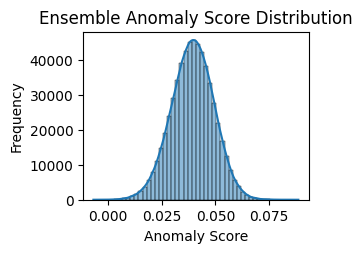

In [5]:
# 3.1 앙상블 점수 분포 시각화
plt.subplot(2, 2, 1)
sns.histplot(df["score_ensemble"], bins=50, kde=True)
plt.title("Ensemble Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")

Text(0, 0.5, 'Cumulative Probability')

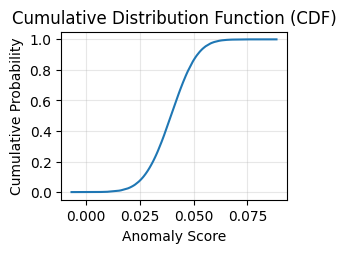

In [6]:
# 3.2 앙상블 점수의 누적 분포 함수 (CDF)
plt.subplot(2, 2, 2)
sorted_scores = np.sort(df["score_ensemble"])
cumulative = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
plt.plot(sorted_scores, cumulative)
plt.grid(True, alpha=0.3)
plt.title("Cumulative Distribution Function (CDF)")
plt.xlabel("Anomaly Score")
plt.ylabel("Cumulative Probability")

Text(0, 0.5, 'Gradient')

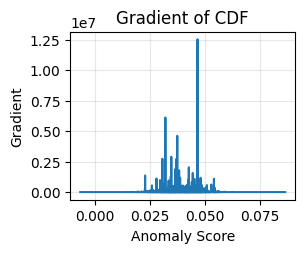

In [7]:
# 변곡점 찾기를 위한 기울기 계산
gradients = np.gradient(cumulative, sorted_scores)
plt.subplot(2, 2, 3)
plt.plot(sorted_scores[:-1], gradients[:-1])
plt.grid(True, alpha=0.3)
plt.title("Gradient of CDF")
plt.xlabel("Anomaly Score")
plt.ylabel("Gradient")

In [11]:
# 3.3 Elbow 방법으로 최적 임계값 찾기
from kneed import KneeLocator
kn = KneeLocator(sorted_scores, cumulative, curve='concave', direction='increasing')
elbow_threshold = kn.knee
print(f"Elbow method threshold: {elbow_threshold}")

Elbow method threshold: -0.006719973153134384


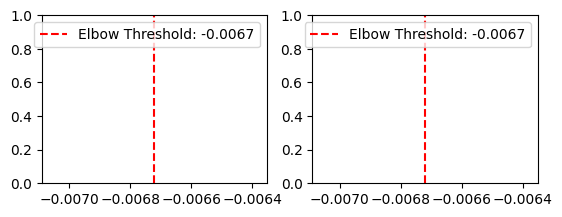

In [12]:
# 3.4 시각화에 elbow point 표시
for i in [1, 2]:
    plt.subplot(2, 2, i)
    plt.axvline(elbow_threshold, color='r', linestyle='--', label=f'Elbow Threshold: {elbow_threshold:.4f}')
    plt.legend()

In [13]:
# 3.5 기울기 변화가 가장 큰 점 찾기
second_derivatives = np.gradient(gradients)
inflection_idx = np.argmax(np.abs(second_derivatives[:-1]))
inflection_threshold = sorted_scores[inflection_idx]
print(f"Inflection point threshold: {inflection_threshold}")


Inflection point threshold: 0.046557954095072275


In [14]:
# 마지막 서브플롯에 변곡점 시각화
plt.subplot(2, 2, 4)
plt.plot(sorted_scores[:-2], second_derivatives[:-2])
plt.grid(True, alpha=0.3)
plt.title("Second Derivative of CDF")
plt.xlabel("Anomaly Score")
plt.ylabel("Second Derivative")
plt.axvline(inflection_threshold, color='g', linestyle='--', 
            label=f'Inflection Threshold: {inflection_threshold:.4f}')
plt.legend()

plt.tight_layout()
plt.savefig("anomaly_score_analysis.png")
plt.close()

In [15]:
# 4. 임계값 결정 방법 비교

# 4.1 고정 백분위수 기반 임계값
percentiles = [90, 95, 97, 99]
percentile_thresholds = {p: np.percentile(df["score_ensemble"], p) for p in percentiles}
print("백분위수 기반 임계값:")
for p, threshold in percentile_thresholds.items():
    print(f"  {p}th percentile: {threshold:.4f}")


백분위수 기반 임계값:
  90th percentile: 0.0518
  95th percentile: 0.0552
  97th percentile: 0.0574
  99th percentile: 0.0617


In [16]:
# 4.2 통계적 방법 기반 임계값 (3-시그마 규칙)
mean_score = np.mean(df["score_ensemble"])
std_score = np.std(df["score_ensemble"])
statistical_threshold = mean_score + 3 * std_score
print(f"통계적 방법 (3-시그마) 임계값: {statistical_threshold:.4f}")


통계적 방법 (3-시그마) 임계값: 0.0689


In [17]:
# 4.3 클러스터링 기반 임계값
# 이 방법은 정상 데이터와 이상 데이터가 클러스터를 형성한다고 가정
pca = PCA(n_components=2)
X_2d = pca.fit_transform(df[["score_ensemble", "score_if", "score_ae"]])
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_2d)

In [18]:
# 4.4 각 클러스터의 평균 점수 확인
cluster_0_mean = df.loc[clusters == 0, "score_ensemble"].mean()
cluster_1_mean = df.loc[clusters == 1, "score_ensemble"].mean()

# 점수가 높은 클러스터를 이상치 클러스터로 간주
if cluster_0_mean > cluster_1_mean:
    anomaly_cluster = 0
    normal_cluster = 1
else:
    anomaly_cluster = 1
    normal_cluster = 0

# 클러스터링 기반 임계값 (두 클러스터 사이의 중간점)
clustering_threshold = (df.loc[clusters == normal_cluster, "score_ensemble"].max() + 
                        df.loc[clusters == anomaly_cluster, "score_ensemble"].min()) / 2
print(f"클러스터링 기반 임계값: {clustering_threshold:.4f}")

클러스터링 기반 임계값: 0.0347


In [19]:
# 클러스터링 결과 시각화
plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='x', s=100)
plt.title("PCA + K-means Clustering of Anomaly Scores")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.savefig("anomaly_clustering.png")
plt.close()

In [20]:
# 5. 최종 임계값 결정: 여러 방법을 종합적으로 고려
# 5.1 각 방법의 결과를 비교
thresholds = {
    "elbow": elbow_threshold,
    "inflection": inflection_threshold,
    "percentile_95": percentile_thresholds[95],
    "percentile_99": percentile_thresholds[99],
    "statistical": statistical_threshold,
    "clustering": clustering_threshold
}

print("\n최종 임계값 후보:")
for method, threshold in thresholds.items():
    print(f"  {method}: {threshold:.4f} (이상치 비율: {(df['score_ensemble'] > threshold).mean()*100:.2f}%)")



최종 임계값 후보:
  elbow: -0.0067 (이상치 비율: 100.00%)
  inflection: 0.0466 (이상치 비율: 23.29%)
  percentile_95: 0.0552 (이상치 비율: 5.00%)
  percentile_99: 0.0617 (이상치 비율: 1.00%)
  statistical: 0.0689 (이상치 비율: 0.12%)
  clustering: 0.0347 (이상치 비율: 68.57%)


In [22]:
# 5.2 검증을 통한 최종 임계값 선택
print("최적 임계값 선택 프로세스 시작...")
print(f"총 {len(thresholds)} 개의 임계값 방법을 평가합니다.")

# 여기서는 실루엣 점수를 사용하여 각 임계값의 클러스터링 품질 평가
silhouette_scores = {}

# 진행 상황 표시를 위한 카운터
total_methods = len(thresholds)
completed = 0

for method, threshold in thresholds.items():
    # 진행 상황 표시
    completed += 1
    progress = (completed / total_methods) * 100
    print(f"[{progress:.1f}%] 방법 '{method}' 평가 중... (임계값: {threshold:.4f})")
    
    # 실루엣 점수 계산
    labels = (df["score_ensemble"] > threshold).astype(int)
    
    # 레이블 분포 표시
    anomaly_count = labels.sum()
    normal_count = len(labels) - anomaly_count
    anomaly_percent = (anomaly_count / len(labels)) * 100
    print(f"  → 정상 샘플: {normal_count}, 이상치 샘플: {anomaly_count} ({anomaly_percent:.2f}%)")
    
    # 각 클래스에 최소 2개 이상의 샘플이 있어야 실루엣 점수 계산 가능
    if anomaly_count >= 2 and normal_count >= 2:
        print("  → 실루엣 점수 계산 중...")
        score = silhouette_score(df[["score_ensemble"]], labels)
        silhouette_scores[method] = score
        print(f"  → 실루엣 점수: {score:.4f}")
    else:
        silhouette_scores[method] = -1  # 유효하지 않은 경우
        print("  → 유효하지 않은 레이블 분포 (최소 2개 이상의 샘플이 각 클래스에 필요)")

# 최적 방법 찾기
if silhouette_scores:
    best_method = max(silhouette_scores, key=silhouette_scores.get)
    best_threshold = thresholds[best_method]
    
    print("\n=== 최종 결과 ===")
    print(f"실루엣 점수가 가장 높은 방법: {best_method} (점수: {silhouette_scores[best_method]:.4f})")
    print(f"이 방법의 임계값: {best_threshold:.4f}")
    
    # 모든 방법의 실루엣 점수 출력
    print("\n모든 방법의 실루엣 점수:")
    for method, score in sorted(silhouette_scores.items(), key=lambda x: x[1], reverse=True):
        print(f"- {method}: {score:.4f} (임계값: {thresholds[method]:.4f})")
else:
    print("\n유효한 실루엣 점수를 계산할 수 없습니다. 데이터 분포를 확인하세요.")

최적 임계값 선택 프로세스 시작...
총 6 개의 임계값 방법을 평가합니다.
[16.7%] 방법 'elbow' 평가 중... (임계값: -0.0067)
  → 정상 샘플: 1, 이상치 샘플: 590539 (100.00%)
  → 유효하지 않은 레이블 분포 (최소 2개 이상의 샘플이 각 클래스에 필요)
[33.3%] 방법 'inflection' 평가 중... (임계값: 0.0466)
  → 정상 샘플: 452982, 이상치 샘플: 137558 (23.29%)
  → 실루엣 점수 계산 중...
  → 실루엣 점수: 0.4849
[50.0%] 방법 'percentile_95' 평가 중... (임계값: 0.0552)
  → 정상 샘플: 561013, 이상치 샘플: 29527 (5.00%)
  → 실루엣 점수 계산 중...
  → 실루엣 점수: 0.4500
[66.7%] 방법 'percentile_99' 평가 중... (임계값: 0.0617)
  → 정상 샘플: 584634, 이상치 샘플: 5906 (1.00%)
  → 실루엣 점수 계산 중...
  → 실루엣 점수: 0.5205
[83.3%] 방법 'statistical' 평가 중... (임계값: 0.0689)
  → 정상 샘플: 589838, 이상치 샘플: 702 (0.12%)
  → 실루엣 점수 계산 중...
  → 실루엣 점수: 0.6188
[100.0%] 방법 'clustering' 평가 중... (임계값: 0.0347)
  → 정상 샘플: 185582, 이상치 샘플: 404958 (68.57%)
  → 실루엣 점수 계산 중...
  → 실루엣 점수: 0.5306

=== 최종 결과 ===
실루엣 점수가 가장 높은 방법: statistical (점수: 0.6188)
이 방법의 임계값: 0.0689

모든 방법의 실루엣 점수:
- statistical: 0.6188 (임계값: 0.0689)
- clustering: 0.5306 (임계값: 0.0347)
- percentile_99: 0.5205 (임계값: 0.06

In [23]:
# 6. Pseudo-label 생성

# 6.1 상한 임계값: 확실한 이상치
upper_threshold = best_threshold

In [24]:
# 6.2 하한 임계값: 확실한 정상 데이터
# 앞서 권장한 대로, 하위 70%를 정상으로 간주
lower_threshold = np.percentile(df["score_ensemble"], 70)

print(f"\n상한 임계값 (확실한 이상치): {upper_threshold:.4f}")
print(f"하한 임계값 (확실한 정상): {lower_threshold:.4f}")


상한 임계값 (확실한 이상치): 0.0689
하한 임계값 (확실한 정상): 0.0446


In [25]:
# 6.3 Pseudo-label 할당
df["pseudo_label"] = -1  # 기본값: 불확실(-1)
df.loc[df["score_ensemble"] > upper_threshold, "pseudo_label"] = 1  # 이상치(1)
df.loc[df["score_ensemble"] < lower_threshold, "pseudo_label"] = 0  # 정상(0)

In [26]:
# 6.4 결과 확인
label_counts = df["pseudo_label"].value_counts()
label_percentages = label_counts / len(df) * 100

print("\nPseudo-label 분포:")
for label, count in label_counts.items():
    label_name = "정상" if label == 0 else "이상" if label == 1 else "불확실"
    print(f"  {label_name}: {count} ({label_percentages[label]:.2f}%)")



Pseudo-label 분포:
  정상: 413378 (70.00%)
  불확실: 176460 (29.88%)
  이상: 702 (0.12%)


In [27]:
# 7. 클래스 불균형 처리: 가중치 계산
if 1 in label_counts and 0 in label_counts:
    weight_ratio = label_counts[0] / label_counts[1]
    print(f"\n클래스 불균형 비율 (정상:이상): {weight_ratio:.2f}:1")
    print(f"LightGBM에서 사용할 scale_pos_weight: {weight_ratio:.4f}")



클래스 불균형 비율 (정상:이상): 588.86:1
LightGBM에서 사용할 scale_pos_weight: 588.8575


In [28]:
# 8. 최종 데이터셋 저장
# 8.1 Pseudo-label이 할당된 전체 데이터셋
df.to_csv("df_with_pseudo_labels.csv", index=False)

In [29]:
# 8.2 학습에 사용할 확실한 샘플만 추출
df_filtered = df[df["pseudo_label"] != -1].copy()
print(f"\n학습에 사용할 확실한 샘플 수: {len(df_filtered)}")
print(f"  정상 샘플: {(df_filtered['pseudo_label'] == 0).sum()}")
print(f"  이상 샘플: {(df_filtered['pseudo_label'] == 1).sum()}")


학습에 사용할 확실한 샘플 수: 414080
  정상 샘플: 413378
  이상 샘플: 702


In [30]:
# 8.3 필요한 특성 추출 준비
# 참고: X_encoded 데이터가 df와 동일한 순서라고 가정
try:
    X_encoded = np.load("X_encoded.npy", allow_pickle=True)
    # df_filtered의 인덱스를 사용하여 해당 샘플의 인코딩된 특성 추출
    X_filtered = X_encoded[df_filtered.index]
    np.save("X_filtered.npy", X_filtered)
    y_filtered = df_filtered["pseudo_label"].values
    np.save("y_filtered.npy", y_filtered)
    print("✅ 특성 및 레이블 추출 완료")
except:
    print("⚠️ X_encoded.npy를 찾을 수 없습니다. 특성 추출 단계를 건너뜁니다.")

✅ 특성 및 레이블 추출 완료


In [31]:
# 9. 추가 분석: 점진적 가중치 부여 방식 준비
# Middle-zone 샘플에 점진적 가중치 부여
middle_mask = (df["score_ensemble"] >= lower_threshold) & (df["score_ensemble"] <= upper_threshold)
middle_samples = df[middle_mask].copy()


In [32]:
# 점수에 따른 선형 확률 계산 (0에 가까울수록 정상, 1에 가까울수록 이상)
middle_samples["prob_anomaly"] = (middle_samples["score_ensemble"] - lower_threshold) / (upper_threshold - lower_threshold)


In [33]:
# 점진적 가중치를 가진 샘플 수
print(f"\n점진적 가중치를 가진 중간 영역 샘플 수: {len(middle_samples)}")



점진적 가중치를 가진 중간 영역 샘플 수: 176460


In [34]:
# 10. 최종 분석 결과 시각화
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

pseudo_label 고유 값: [-1  0  1]


C:\Users\ESPC\AppData\Local\Temp\ipykernel_14136\657514372.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="pseudo_label", data=df,
C:\Users\ESPC\AppData\Local\Temp\ipykernel_14136\657514372.py:21: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ESPC\AppData\Local\Temp\ipykernel_14136\657514372.py:21: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ESPC\AppData\Local\Temp\ipykernel_14136\657514372.py:21: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ESPC\AppData\Local\Temp\ipykernel_14136\657514372.py:21: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ESPC\App

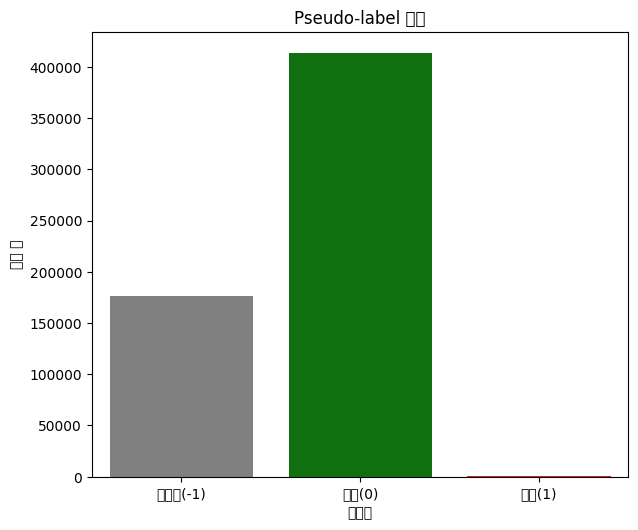

In [37]:
# 10.1 Pseudo-label 분포 시각화
plt.figure(figsize=(12, 10))

# 먼저 pseudo_label의 고유 값 확인
print("pseudo_label 고유 값:", df["pseudo_label"].unique())

# 코드 수정
plt.subplot(2, 2, 1)

# 두 가지 방법 중 하나를 선택하세요:

# 방법 1: 문자열 키로 수정
sns.countplot(x="pseudo_label", data=df, 
              order=['-1', '0', '1'],
              palette={'-1': 'gray', '0': 'green', '1': 'red'})
plt.xticks([0, 1, 2], ['불확실(-1)', '정상(0)', '이상(1)'])
plt.title("Pseudo-label 분포")
plt.xlabel("클래스")
plt.ylabel("샘플 수")

plt.tight_layout()
plt.show()

c:\Users\ESPC\Desktop\음성송금\voice_venv\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\ESPC\Desktop\음성송금\voice_venv\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\ESPC\Desktop\음성송금\voice_venv\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\ESPC\Desktop\음성송금\voice_venv\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\ESPC\Desktop\음성송금\voice_venv\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\ESPC\Desktop\음성송금\voice_venv\lib

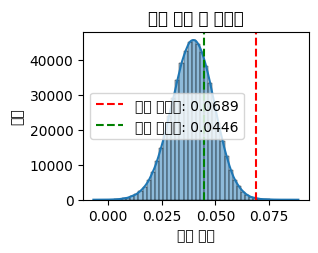

In [38]:
# 10.2 점수 분포와 임계값 시각화
plt.subplot(2, 2, 2)
sns.histplot(df["score_ensemble"], bins=50, kde=True)
plt.axvline(upper_threshold, color='r', linestyle='--', label=f'상한 임계값: {upper_threshold:.4f}')
plt.axvline(lower_threshold, color='g', linestyle='--', label=f'하한 임계값: {lower_threshold:.4f}')
plt.title("점수 분포 및 임계값")
plt.xlabel("이상 점수")
plt.ylabel("빈도")
plt.legend()


c:\Users\ESPC\Desktop\음성송금\voice_venv\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\ESPC\Desktop\음성송금\voice_venv\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\ESPC\Desktop\음성송금\voice_venv\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\ESPC\Desktop\음성송금\voice_venv\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\ESPC\Desktop\음성송금\voice_venv\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\ESPC\Desktop\음성송금\voice_venv\

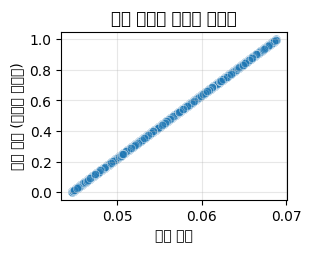

In [39]:
# 10.3 중간 영역의 점진적 가중치 시각화
if len(middle_samples) > 0:
    plt.subplot(2, 2, 3)
    sns.scatterplot(x="score_ensemble", y="prob_anomaly", data=middle_samples, alpha=0.5)
    plt.title("중간 영역의 점진적 가중치")
    plt.xlabel("이상 점수")
    plt.ylabel("이상 확률 (점진적 가중치)")
    plt.grid(True, alpha=0.3)


C:\Users\ESPC\AppData\Local\Temp\ipykernel_14136\788518750.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="pseudo_label", y="score_ensemble", data=df,



✅ Pseudo-labeling 완료!
df_with_pseudo_labels.csv로 결과가 저장되었습니다.
pseudo_labeling_analysis.png로 시각화 결과가 저장되었습니다.


C:\Users\ESPC\AppData\Local\Temp\ipykernel_14136\788518750.py:11: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ESPC\AppData\Local\Temp\ipykernel_14136\788518750.py:11: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ESPC\AppData\Local\Temp\ipykernel_14136\788518750.py:11: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ESPC\AppData\Local\Temp\ipykernel_14136\788518750.py:11: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ESPC\AppData\Local\Temp\ipykernel_14136\788518750.py:11: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ESPC\AppData\Local\Temp\ipykernel_14136\788518750.py:11: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) 

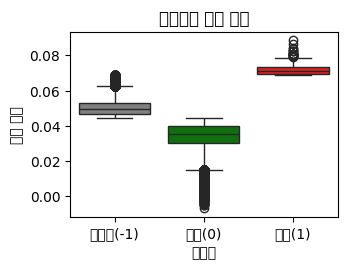

In [41]:
# 10.4 레이블별 점수 분포 비교
plt.subplot(2, 2, 4)
sns.boxplot(x="pseudo_label", y="score_ensemble", data=df, 
            order=['-1', '0', '1'],  # 문자열로 변경
            palette={'-1': 'gray', '0': 'green', '1': 'red'})  # 문자열 키로 변경
plt.xticks([0, 1, 2], ['불확실(-1)', '정상(0)', '이상(1)'])
plt.title("레이블별 점수 분포")
plt.xlabel("클래스")
plt.ylabel("이상 점수")

plt.tight_layout()
plt.savefig("pseudo_labeling_analysis.png")

print("\n✅ Pseudo-labeling 완료!")
print("df_with_pseudo_labels.csv로 결과가 저장되었습니다.")
print("pseudo_labeling_analysis.png로 시각화 결과가 저장되었습니다.")